In [4]:
!pip install -q open-clip-torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.2 MB/s eta 0:00:00


In [5]:
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
from datasets import load_dataset
from diffusers import DDIMScheduler, DDPMPipeline
from matplotlib import pyplot as plt
from PIL import Image
from torchvision import transforms
from tqdm.auto import tqdm

import open_clip

In [6]:
device = ("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
device

'cuda'

# Inference Pipeline

In [3]:
image_pipeline= DDPMPipeline.from_pretrained("google/ddpm-celebahq-256")
image_pipeline.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


DDPMPipeline {
  "_class_name": "DDPMPipeline",
  "_diffusers_version": "0.36.0",
  "_name_or_path": "google/ddpm-celebahq-256",
  "scheduler": [
    "diffusers",
    "DDPMScheduler"
  ],
  "unet": [
    "diffusers",
    "UNet2DModel"
  ]
}

  0%|          | 0/1000 [00:00<?, ?it/s]

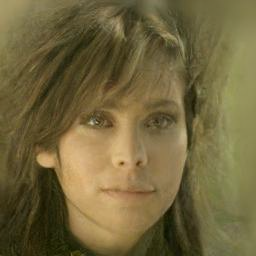

In [4]:
images= image_pipeline().images
images[0]

In [5]:
scheduler= DDIMScheduler.from_pretrained("google/ddpm-celebahq-256")
scheduler.set_timesteps(num_inference_steps=50)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [6]:
scheduler.timesteps

tensor([980, 960, 940, 920, 900, 880, 860, 840, 820, 800, 780, 760, 740, 720,
        700, 680, 660, 640, 620, 600, 580, 560, 540, 520, 500, 480, 460, 440,
        420, 400, 380, 360, 340, 320, 300, 280, 260, 240, 220, 200, 180, 160,
        140, 120, 100,  80,  60,  40,  20,   0])

0it [00:00, ?it/s]

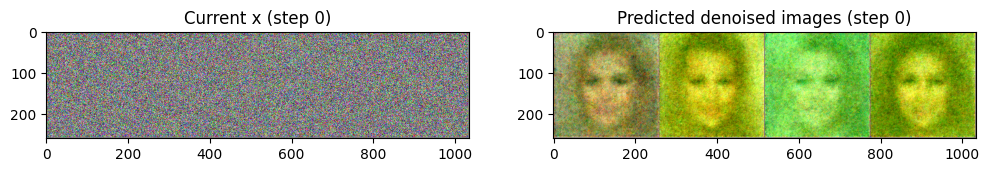

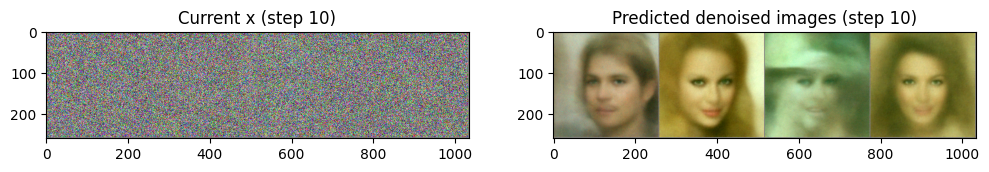

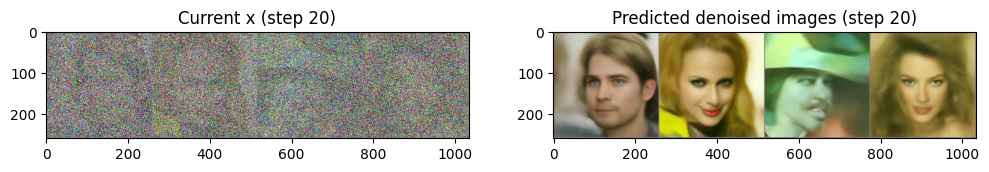

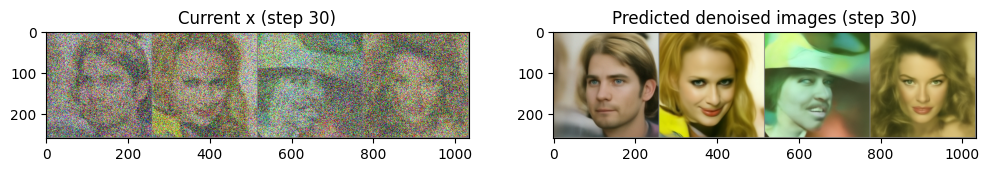

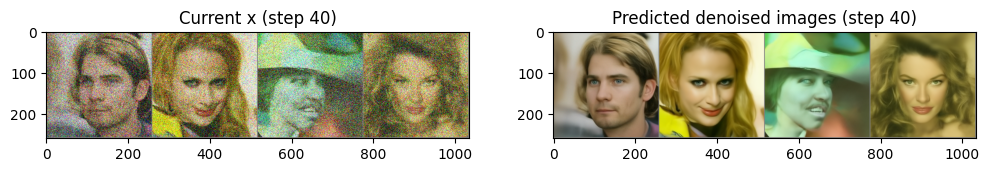

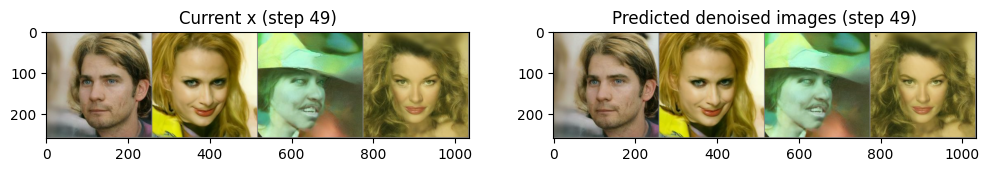

In [7]:
x = torch.randn(4, 3, 256, 256).to(device)

for i, t in tqdm(enumerate(scheduler.timesteps)):

    model_input = scheduler.scale_model_input(x, t)

    with torch.no_grad():
        noise_pred = image_pipeline.unet(model_input, t)["sample"]

    scheduler_output = scheduler.step(noise_pred, t, x)

    x = scheduler_output.prev_sample

    if i % 10 == 0 or i == len(scheduler.timesteps) - 1:
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))

        grid = torchvision.utils.make_grid(x, nrow=4).permute(1, 2, 0)
        axs[0].imshow(grid.cpu().clip(-1, 1) * 0.5 + 0.5)
        axs[0].set_title(f"Current x (step {i})")

        pred_x0 = (scheduler_output.pred_original_sample)
        grid = torchvision.utils.make_grid(pred_x0, nrow=4).permute(1, 2, 0)
        axs[1].imshow(grid.cpu().clip(-1, 1) * 0.5 + 0.5)
        axs[1].set_title(f"Predicted denoised images (step {i})")
        plt.show()

  0%|          | 0/40 [00:00<?, ?it/s]

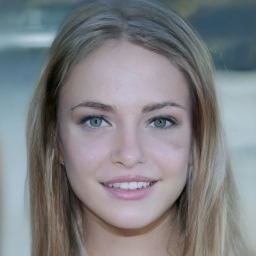

In [9]:
image_pipeline.scheduler = scheduler
images = image_pipeline(num_inference_steps=40).images
images[0]

# Fine tuning

In [3]:
dataset_name = "huggan/few-shot-anime-face"
dataset = load_dataset(dataset_name, split="train")
image_size = 256
batch_size = 4
preprocess = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

def transform(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}

# dataset= dataset[0:1000]
dataset.set_transform(transform)

train_dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/676 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json:   0%|          | 0.00/657 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/7.81M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120 [00:00<?, ? examples/s]

Previewing batch:


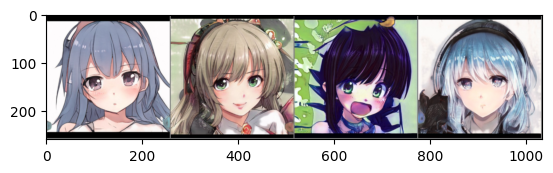

In [4]:
print("Previewing batch:")
batch = next(iter(train_dataloader))
grid = torchvision.utils.make_grid(batch["images"], nrow=4)
plt.imshow(grid.permute(1, 2, 0).cpu().clip(-1, 1) * 0.5 + 0.5);

In [9]:
image_pipeline= DDPMPipeline.from_pretrained("google/ddpm-celebahq-256")
image_pipeline.to(device)
scheduler= DDIMScheduler.from_pretrained("google/ddpm-celebahq-256")
scheduler.set_timesteps(num_inference_steps=50)
image_pipeline.scheduler = scheduler

model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 0:
 loss: 0.032747658776740234 

New best loss found: 0.032747658776740234 (Previous: inf). Saving model...


  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1:
 loss: 0.022550067840105232 

New best loss found: 0.022550067840105232 (Previous: 0.032747658776740234). Saving model...


  0%|          | 0/30 [00:00<?, ?it/s]

...

Epoch 7:
 loss: 0.01208307031968919 



  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 8:
 loss: 0.011160341996583157 



  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 9:
 loss: 0.010456357583946859 



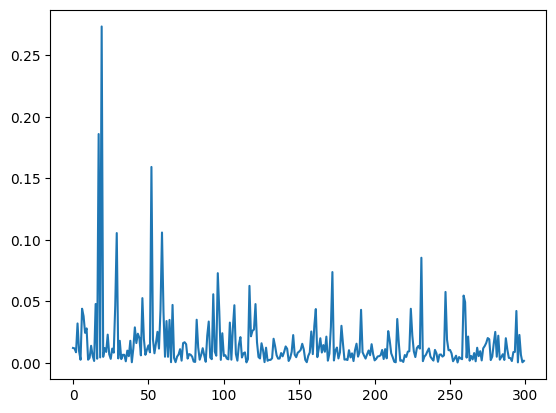

In [7]:
num_epoch = 10
optimizer = torch.optim.AdamW(image_pipeline.unet.parameters(), lr=1e-5)
grad_accumulation_step = 2

losses = []
best_loss = float('inf')

for epoch in range(num_epoch):
    for step, batch in tqdm(enumerate(train_dataloader), total=len(train_dataloader)):
        clean_images = batch["images"].to(device)

        noise = torch.randn(clean_images.shape).to(clean_images.device)
        bs = clean_images.shape[0]

        timesteps = torch.randint(0, image_pipeline.scheduler.config.num_train_timesteps, (bs,), device=clean_images.device).long()

        noisy_images = image_pipeline.scheduler.add_noise(clean_images, noise, timesteps)

        noise_pred = image_pipeline.unet(noisy_images, timesteps, return_dict=False)[0]

        raw_loss = F.mse_loss(noise_pred, noise)
        losses.append(raw_loss.item())

        loss = raw_loss / grad_accumulation_step
        loss.backward()

        if (step + 1) % grad_accumulation_step == 0:
            optimizer.step()
            optimizer.zero_grad()
    avg_epoch_loss= sum(losses[-len(train_dataloader): ]) / len(train_dataloader)
    print(f"Epoch {epoch}:\n loss: {avg_epoch_loss} \n")
    if avg_epoch_loss < best_loss:
        print(f"New best loss found: {avg_epoch_loss} (Previous: {best_loss}). Saving model...")
        best_loss = avg_epoch_loss

        image_pipeline.save_pretrained("./best-anime-ddpm-model")

plt.plot(losses)

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


  0%|          | 0/50 [00:00<?, ?it/s]

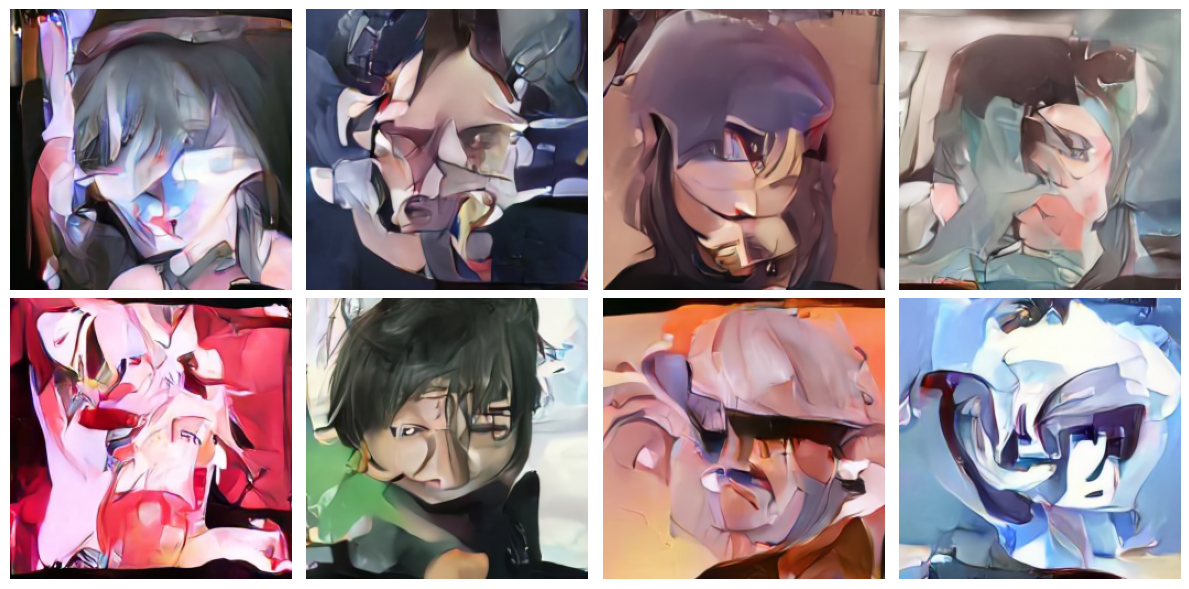

In [12]:
my_pipeline = DDPMPipeline.from_pretrained("./best-anime-ddpm-model").to(device)

# Optional: If you want to use DDIM instead of DDPM for faster inference (50 steps)
from diffusers import DDIMScheduler
my_pipeline.scheduler = DDIMScheduler.from_pretrained("google/ddpm-celebahq-256")

# 2. GENERATE IMAGES
# The pipeline handles the random noise initialization and the loop internally
generated_images = my_pipeline(batch_size=8, num_inference_steps=50).images

# 3. PLOT THE RESULTS
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated_images[i])
    ax.axis("off")
plt.tight_layout()
plt.show()

0it [00:00, ?it/s]

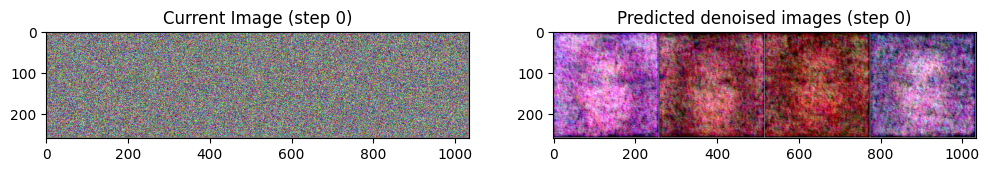

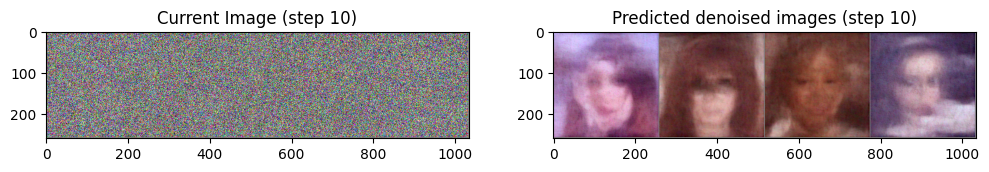

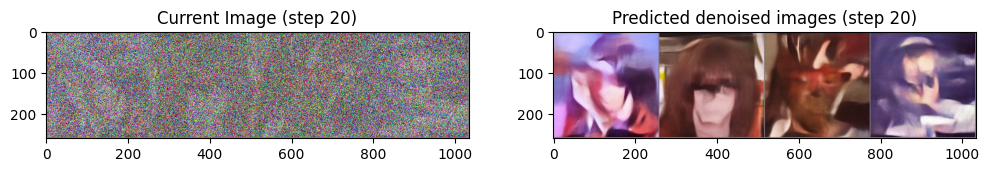

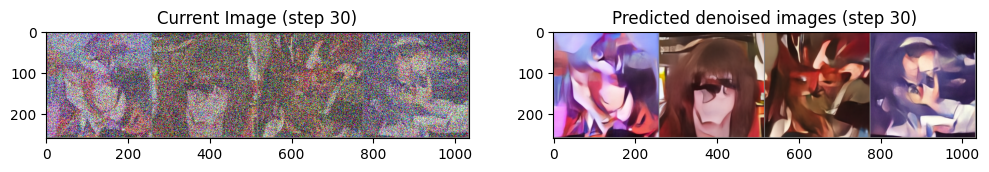

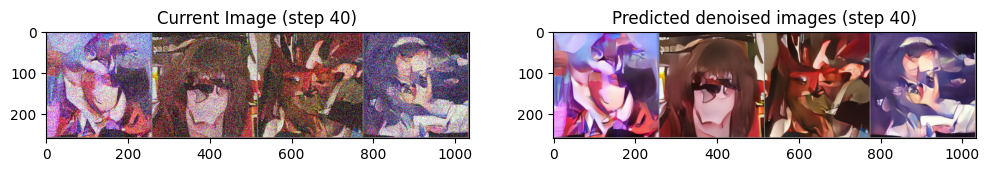

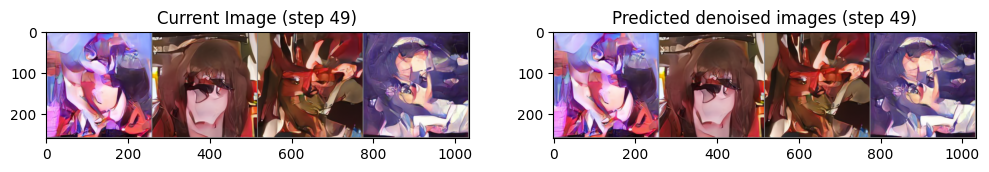

In [13]:
x = torch.randn(4, 3, 256, 256).to(device)

for i, t in tqdm(enumerate(scheduler.timesteps)):

    model_input = scheduler.scale_model_input(x, t)

    with torch.no_grad():
        noise_pred = my_pipeline.unet(model_input, t)["sample"]

    scheduler_output = scheduler.step(noise_pred, t, x)

    x = scheduler_output.prev_sample

    if i % 10 == 0 or i == len(scheduler.timesteps) - 1:
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))

        grid = torchvision.utils.make_grid(x, nrow=4).permute(1, 2, 0)
        axs[0].imshow(grid.cpu().clip(-1, 1) * 0.5 + 0.5)
        axs[0].set_title(f"Current Image (step {i})")

        pred_x0 = (scheduler_output.pred_original_sample)
        grid = torchvision.utils.make_grid(pred_x0, nrow=4).permute(1, 2, 0)
        axs[1].imshow(grid.cpu().clip(-1, 1) * 0.5 + 0.5)
        axs[1].set_title(f"Predicted denoised images (step {i})")
        plt.show()

# Guidance

In [18]:
def color_loss(images, target_color=(0.1, 0.9, 0.5)):

  target= (torch.Tensor(target_color).to(images.device)* 2 - 1)

  target= target[None, :, None, None]

  error= torch.abs(images- target).mean()
  return error

0it [00:00, ?it/s]

0 Loss: 49.44121170043945
10 Loss: 16.36979866027832
20 Loss: 30.72150993347168
30 Loss: 35.06721115112305
40 Loss: 35.763675689697266


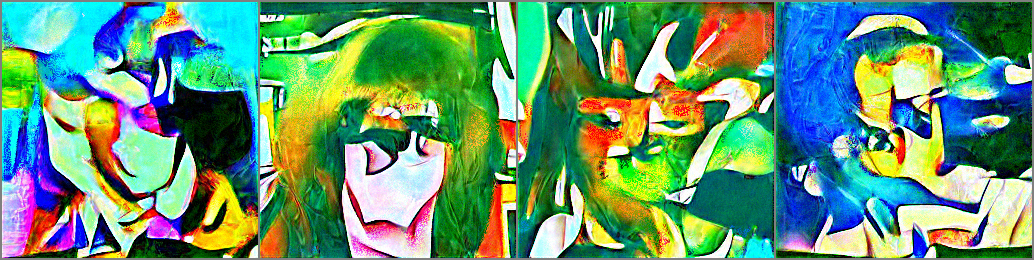

In [19]:
guidance_loss_scale= 50 # decides the strength of effect of guidance

x= torch.randn(4, 3, 256, 256).to(device)

for i, t in tqdm(enumerate(scheduler.timesteps)):
  model_imput= scheduler.scale_model_input(x, t)

  with torch.no_grad():
    noise_pred= my_pipeline.unet(model_input, t)["sample"]

  x= x.detach().requires_grad_()

  x0= scheduler.step(noise_pred, t, x).pred_original_sample

  loss= color_loss(x0) * guidance_loss_scale

  if i%10 == 0:
    print(i, "Loss:", loss.item())

  cond_grad= -torch.autograd.grad(loss, x)[0]
  x= x.detach() + cond_grad
  x= scheduler.step(noise_pred, t, x).prev_sample

grid = torchvision.utils.make_grid(x, nrow=4)
im = grid.permute(1, 2, 0).cpu().clip(-1, 1) * 0.5 + 0.5
Image.fromarray(np.array(im * 255).astype(np.uint8))

0it [00:00, ?it/s]

0 loss: 7.022390365600586
10 loss: 5.6229658126831055
20 loss: 5.544223785400391
30 loss: 5.653469562530518
40 loss: 5.714280605316162


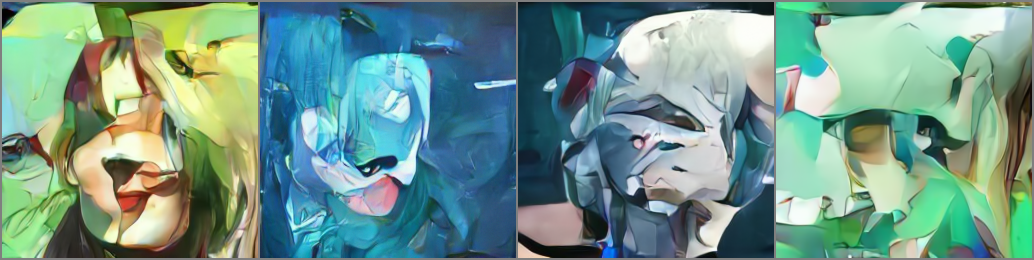

In [23]:
guidance_loss_scale = 10
x = torch.randn(4, 3, 256, 256).to(device)

for i, t in tqdm(enumerate(scheduler.timesteps)):

    x = x.detach().requires_grad_()
    model_input = scheduler.scale_model_input(x, t)

    noise_pred = my_pipeline.unet(model_input, t)["sample"]

    x0 = scheduler.step(noise_pred, t, x).pred_original_sample

    loss = color_loss(x0) * guidance_loss_scale
    if i % 10 == 0:
        print(i, "loss:", loss.item())

    cond_grad = -torch.autograd.grad(loss, x)[0]

    x = x.detach() + cond_grad
    x = scheduler.step(noise_pred, t, x).prev_sample

grid = torchvision.utils.make_grid(x, nrow=4)
im = grid.permute(1, 2, 0).cpu().clip(-1, 1) * 0.5 + 0.5
Image.fromarray(np.array(im * 255).astype(np.uint8))

# CLIP Guidance

In [7]:
clip_model, _, preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
clip_model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-11): 12 x ResidualAttentionBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((768,), eps=1e-05, elementwise_affine

In [8]:
tfms= torchvision.transforms.Compose(
    [
        torchvision.transforms.RandomResizedCrop(224),
        torchvision.transforms.RandomAffine(5),
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.Normalize(
            mean=(0.48145466, 0.4578275, 0.40821073),
            std=(0.26862954, 0.26130258, 0.27577711)
        )
    ]
)

def clip_loss(image, text_features):
  image_features= clip_model.encode_image(tfms(image))

  input_normed = torch.nn.functional.normalize(image_features.unsqueeze(1), dim=2)
  embed_normed = torch.nn.functional.normalize(text_features.unsqueeze(0), dim=2)

  dists= (input_normed.sub(embed_normed).norm(dim=2).div(2).arcsin().pow(2).mul(2))

  return dists.mean()

/tmp/ipython-input-2654474557.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():


0it [00:00, ?it/s]

Step 25, Guidance_loss: 0.8901178240776062
Step 50, Guidance_loss: 0.8674724698066711


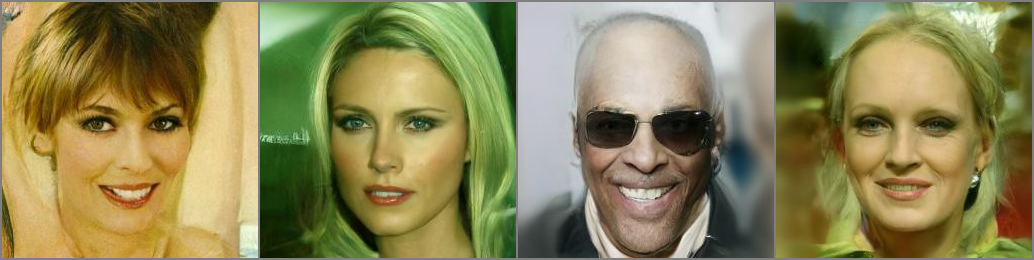

In [32]:
prompt = "smiling"
guidance_scale=1
n_cuts= 8

scheduler.set_timesteps(50)

text= open_clip.tokenize([prompt]).to(device)
with torch.no_grad(), torch.cuda.amp.autocast():
  text_features= clip_model.encode_text(text)

x= torch.randn(4, 3, 256, 256).to(device)

for i, t in tqdm(enumerate(scheduler.timesteps, start=1)):
  model_input= scheduler.scale_model_input(x, t)

  with torch.no_grad():
    noise_pred= image_pipeline.unet(model_input, t)["sample"]

  cond_grad= 0

  for cut in range(n_cuts):
    x = x.detach().requires_grad_()
    x0 = scheduler.step(noise_pred, t, x).pred_original_sample
    loss = clip_loss(x0, text_features) * guidance_scale
    cond_grad -= torch.autograd.grad(loss, x)[0] / n_cuts

  if i% 25 ==0:
    print(f"Step {i}, Guidance_loss: {loss.item()}")

  alpha_bar= scheduler.alphas_cumprod[i]
  x= (x.detach() + cond_grad* alpha_bar.sqrt())
  x= scheduler.step(noise_pred, t, x).prev_sample


grid = torchvision.utils.make_grid(x.detach(), nrow=4)
im = grid.permute(1, 2, 0).cpu().clip(-1, 1) * 0.5 + 0.5
Image.fromarray(np.array(im * 255).astype(np.uint8))